# BigBasket Customer Retention Analysis
## Exploratory Data Analysis

**Research Question:**  
*How can BigBasket increase its monthly customer retention by 3% through data-driven marketing strategies and predictive churn modeling?*

**Project Objectives:**
1. Understand current customer behavior and transaction patterns
2. Identify key churn indicators and at-risk customer segments
3. Analyze retention drivers across different customer cohorts
4. Provide actionable insights for targeted retention campaigns

**Date:** February 2026  
**Dataset:** BigBasket Order-Level Transactional Data

## 1. Import Libraries and Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [ ]:
# Install required package for reading Excel files
%pip install openpyxl

## 2. Load Dataset

In [5]:
# Load dataset
df = pd.read_excel("raw data.xlsx")

# Basic inspection
df.head()

,order_delivery_date_id,source_order_header_id,source_member_id,source_city_name,location_name,source_location_type,payment_type,member_id,source_slug,member_class,member_state,evoucher_code,order_count,qty,total_sales,last_order_date,refund_amount,refund_orders,delivery_date
0,20251126,1837962888,16265039,Gurgaon,DS-BNGUR-Sector-85,LT-IBBN,NEUCOINS,16697711,bbnow,Silver,Intermittent,&,1,4.13,213.76,2025-11-30,0.00,0,2025-11-26
1,20251121,1828973146,11488782,Chandigarh Tricity,DS-IBMOH-ISBT Ludhia,IBBN,PAY,11623177,bb-b2c,Silver,Intermittent,&,1,8.08,80.80,2025-11-23,0.00,0,2025-11-21
2,20251125,1837360421,21806809,Bangalore,DS-IBBLR-BrigadeRoad,IBBN,UPI_QR,22545457,bbnow,Silver,Intermittent,&,1,4.00,118.53,2025-11-27,0.00,0,2025-11-25
3,20251106,1821995270,6143232,Bangalore,DS-IBBLR-Manyata,LT-IBBN,PAY,6236154,bbnow,Silver,Intermittent,&,1,16.17,"1,036.51",2025-11-15,0.00,0,2025-11-06
4,20251130,1841246009,1733139,Hyderabad,DS-IBHYD-Tarnaka,IBBN,VISA,923163,bbnow,Silver,Intermittent,&,1,1.00,229.00,2025-11-30,0.00,0,2025-11-30


## 3. Dataset Overview

In [6]:
# Shape of dataset
print("Dataset shape:", df.shape)

Dataset shape: (13406, 19)


In [7]:
# Column data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13406 entries, 0 to 13405
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_delivery_date_id  13406 non-null  int64         
 1   source_order_header_id  13406 non-null  int64         
 2   source_member_id        13406 non-null  int64         
 3   source_city_name        13406 non-null  object        
 4   location_name           13406 non-null  object        
 5   source_location_type    13406 non-null  object        
 6   payment_type            13406 non-null  object        
 7   member_id               13406 non-null  int64         
 8   source_slug             13406 non-null  object        
 9   member_class            13406 non-null  object        
 10  member_state            13406 non-null  object        
 11  evoucher_code           13406 non-null  object        
 12  order_count             13406 non-null  int64 

In [8]:
# Summary statistics
df.describe(include="all")

,order_delivery_date_id,source_order_header_id,source_member_id,source_city_name,location_name,source_location_type,payment_type,member_id,source_slug,member_class,member_state,evoucher_code,order_count,qty,total_sales,last_order_date,refund_amount,refund_orders,delivery_date
count,"13,406.00","13,406.00","13,406.00",13406,13406,13406,13406,"13,406.00",13406,13406,13406,13406,"13,406.00","13,406.00","13,406.00",13406,"13,406.00","13,406.00",13406
unique,NaN,NaN,NaN,50,819,6,22,NaN,7,1,1,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Bangalore,DS-IBBHU-KIIT Road,IBBN,PAY,NaN,bbnow,Silver,Intermittent,&,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2022,62,7210,5466,NaN,10974,13406,13406,10995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,"20,251,115.39","1,829,284,340.78","35,963,401.44",NaN,NaN,NaN,NaN,"39,011,255.20",NaN,NaN,NaN,NaN,1.00,6.00,465.75,2025-11-20 10:15:22.691332352,6.07,0.04,2025-11-15 09:23:16.926749184
min,"20,251,101.00","1,814,528,933.00",954.00,NaN,NaN,NaN,NaN,180.00,NaN,NaN,NaN,NaN,1.00,0.06,0.60,2025-11-01 00:00:00,0.00,0.00,2025-11-01 00:00:00
25%,"20,251,108.00","1,823,329,692.75","17,815,382.50",NaN,NaN,NaN,NaN,"17,903,727.00",NaN,NaN,NaN,NaN,1.00,2.00,183.93,2025-11-15 00:00:00,0.00,0.00,2025-11-08 00:00:00
50%,"20,251,115.00","1,829,204,459.00","34,292,501.00",NaN,NaN,NaN,NaN,"35,022,766.00",NaN,NaN,NaN,NaN,1.00,5.00,278.23,2025-11-23 00:00:00,0.00,0.00,2025-11-15 00:00:00
75%,"20,251,123.00","1,835,427,108.50","54,584,055.75",NaN,NaN,NaN,NaN,"55,285,451.00",NaN,NaN,NaN,NaN,1.00,8.00,502.96,2025-11-28 00:00:00,0.00,0.00,2025-11-23 00:00:00
max,"20,251,130.00","1,841,619,286.00","77,327,494.00",NaN,NaN,NaN,NaN,"118,628,706.00",NaN,NaN,NaN,NaN,1.00,94.00,"99,990.00",2025-11-30 00:00:00,"3,189.00",6.00,2025-11-30 00:00:00


## 4. Missing Value Analysis

In [9]:
# Missing values count and percentage
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": df.isnull().mean() * 100
}).sort_values("missing_pct", ascending=False)

missing

,missing_count,missing_pct
order_delivery_date_id,0,0.00
member_state,0,0.00
refund_orders,0,0.00
refund_amount,0,0.00
last_order_date,0,0.00
total_sales,0,0.00
qty,0,0.00
order_count,0,0.00
evoucher_code,0,0.00
member_class,0,0.00


## 5. Feature Engineering - Date Processing

In [10]:
# Convert date columns
date_cols = ["delivery_date", "last_order_date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Create recency feature
df["days_since_last_order"] = (
    df["delivery_date"] - df["last_order_date"]
).dt.days

df[["delivery_date", "last_order_date", "days_since_last_order"]].head()

,delivery_date,last_order_date,days_since_last_order
0,2025-11-26,2025-11-30,-4
1,2025-11-21,2025-11-23,-2
2,2025-11-25,2025-11-27,-2
3,2025-11-06,2025-11-15,-9
4,2025-11-30,2025-11-30,0


## 6. Customer-Level Aggregation

In [11]:
customer_agg = df.groupby("member_id").agg(
    total_orders=("source_order_header_id", "nunique"),
    total_sales=("total_sales", "sum"),
    avg_order_value=("total_sales", "mean"),
    avg_basket_size=("qty", "mean"),
    refund_rate=("refund_orders", "mean"),
    last_delivery_date=("delivery_date", "max"),
    first_delivery_date=("delivery_date", "min"),
    city=("source_city_name", "first"),
    member_class=("member_class", "first"),
    service_type=("source_slug", "first")
).reset_index()

customer_agg["customer_lifetime_days"] = (
    customer_agg["last_delivery_date"] - customer_agg["first_delivery_date"]
).dt.days

customer_agg.head()

,member_id,total_orders,total_sales,avg_order_value,avg_basket_size,refund_rate,last_delivery_date,first_delivery_date,city,member_class,service_type,customer_lifetime_days
0,180,1,475.10,475.10,5.03,1.00,2025-11-15,2025-11-15,Hyderabad,Silver,bbnow,0
1,5782,1,837.70,837.70,14.39,0.00,2025-11-06,2025-11-06,Guwahati,Silver,bbnow,0
2,6192,1,203.80,203.80,6.18,0.00,2025-11-29,2025-11-29,Hyderabad,Silver,bbnow,0
3,12043,1,336.87,336.87,3.00,0.00,2025-11-29,2025-11-29,Mumbai,Silver,bb-b2c,0
4,21280,1,207.24,207.24,6.03,0.00,2025-11-13,2025-11-13,Hyderabad,Silver,bbnow,0


## 7. Distribution Analysis

### 7.1 Order Frequency Distribution

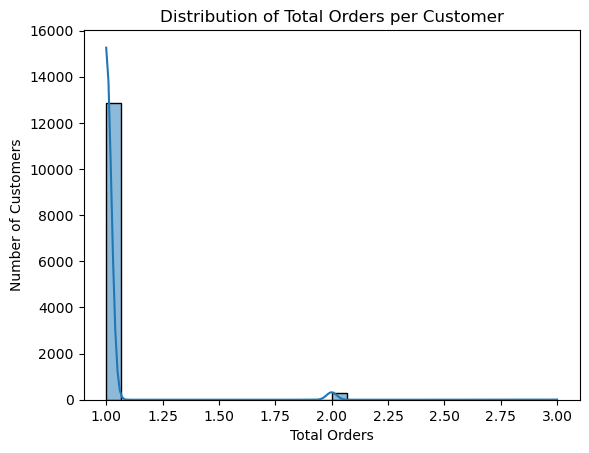

In [12]:
plt.figure()
sns.histplot(customer_agg["total_orders"], bins=30, kde=True)
plt.title("Distribution of Total Orders per Customer")
plt.xlabel("Total Orders")
plt.ylabel("Number of Customers")
plt.show()

### 7.2 Order Value and Basket Size Distribution

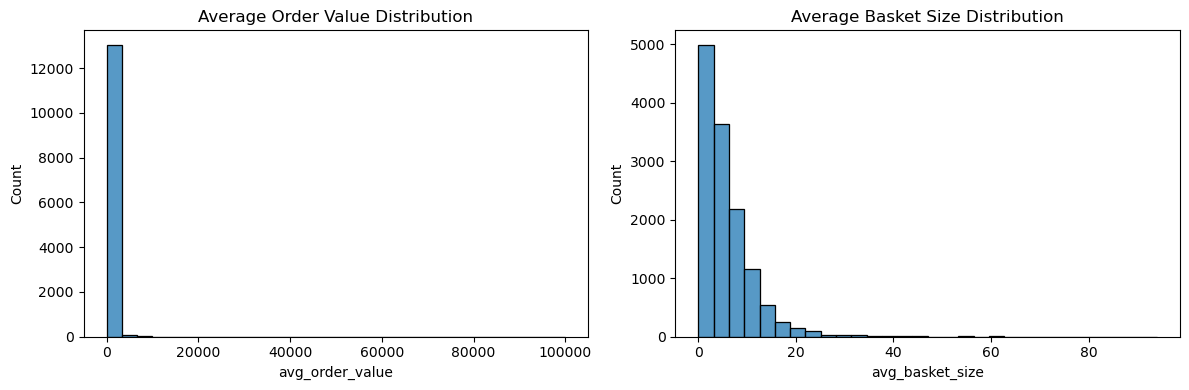

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(customer_agg["avg_order_value"], bins=30, ax=axes[0])
axes[0].set_title("Average Order Value Distribution")

sns.histplot(customer_agg["avg_basket_size"], bins=30, ax=axes[1])
axes[1].set_title("Average Basket Size Distribution")

plt.tight_layout()
plt.show()

## 8. Segmentation Analysis

### 8.1 Refund Rate by Member Class

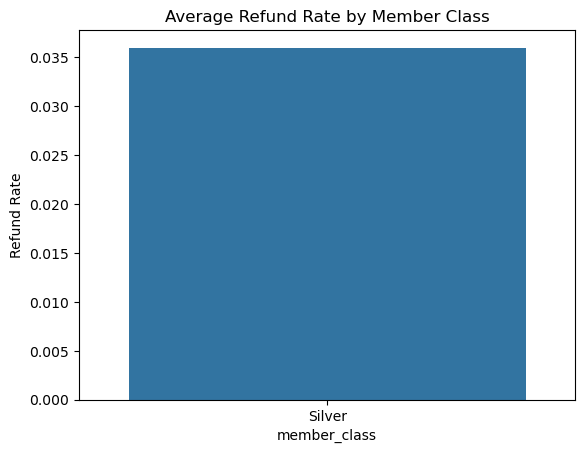

In [14]:
# Refund rate by customer class
refund_by_class = customer_agg.groupby("member_class")["refund_rate"].mean().reset_index()

plt.figure()
sns.barplot(data=refund_by_class, x="member_class", y="refund_rate")
plt.title("Average Refund Rate by Member Class")
plt.ylabel("Refund Rate")
plt.show()

### 8.2 Geographic Distribution - Top Cities

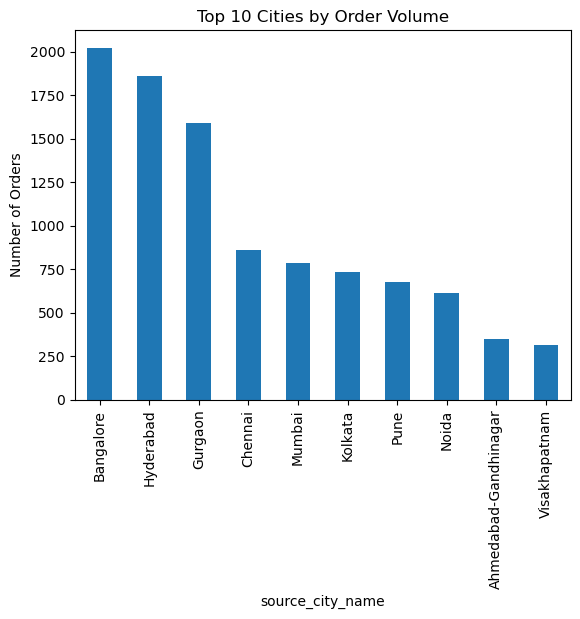

In [15]:
# Orders by city
top_cities = df["source_city_name"].value_counts().head(10)

plt.figure()
top_cities.plot(kind="bar")
plt.title("Top 10 Cities by Order Volume")
plt.ylabel("Number of Orders")
plt.show()

### 8.3 Service Type Performance Comparison

In [16]:
# Service type comparison
service_metrics = df.groupby("source_slug").agg(
    avg_order_value=("total_sales", "mean"),
    refund_rate=("refund_orders", "mean"),
    order_count=("source_order_header_id", "nunique")
).reset_index()

service_metrics

,source_slug,avg_order_value,refund_rate,order_count
0,bb-3pl,450.50,0.00,1
1,bb-b2c,553.97,0.04,1811
2,bb-food,265.82,0.00,38
3,bb-pharma,466.42,0.00,17
4,bbnow,448.43,0.04,10974
5,tataneu-b2c,696.54,0.01,101
6,tataneu-bbnow,497.02,0.02,464


---
## 9. CHURN ANALYSIS - Core Research Focus

### 9.1 Define Churn Label
For churn modeling, we need to define what constitutes a "churned" customer.

In [17]:
# Define churn based on inactivity period
# Standard approach: 30, 60, or 90 days of inactivity
from datetime import datetime

# Assuming analysis date is the max delivery date in dataset
analysis_date = df['delivery_date'].max()
print(f"Analysis Date (Latest Order in Dataset): {analysis_date}")

# Calculate days since last purchase for each customer
customer_agg['days_since_last_purchase'] = (analysis_date - customer_agg['last_delivery_date']).dt.days

# Define churn thresholds (you can test multiple)
CHURN_THRESHOLD_30 = 30  # 30 days
CHURN_THRESHOLD_60 = 60  # 60 days  
CHURN_THRESHOLD_90 = 90  # 90 days

# Create churn labels
customer_agg['churned_30d'] = (customer_agg['days_since_last_purchase'] > CHURN_THRESHOLD_30).astype(int)
customer_agg['churned_60d'] = (customer_agg['days_since_last_purchase'] > CHURN_THRESHOLD_60).astype(int)
customer_agg['churned_90d'] = (customer_agg['days_since_last_purchase'] > CHURN_THRESHOLD_90).astype(int)

# Display churn rates
print("\n" + "="*60)
print("CHURN RATE ANALYSIS")
print("="*60)
print(f"30-Day Churn Rate: {customer_agg['churned_30d'].mean()*100:.2f}%")
print(f"60-Day Churn Rate: {customer_agg['churned_60d'].mean()*100:.2f}%")
print(f"90-Day Churn Rate: {customer_agg['churned_90d'].mean()*100:.2f}%")
print(f"\nTotal Customers: {len(customer_agg):,}")
print(f"Active Customers (< 30 days): {(customer_agg['churned_30d']==0).sum():,}")
print(f"Churned Customers (> 30 days): {customer_agg['churned_30d'].sum():,}")

customer_agg[['member_id', 'days_since_last_purchase', 'churned_30d', 'churned_60d', 'churned_90d']].head(10)

Analysis Date (Latest Order in Dataset): 2025-11-30 00:00:00

CHURN RATE ANALYSIS
30-Day Churn Rate: 0.00%
60-Day Churn Rate: 0.00%
90-Day Churn Rate: 0.00%

Total Customers: 13,120
Active Customers (< 30 days): 13,120
Churned Customers (> 30 days): 0


,member_id,days_since_last_purchase,churned_30d,churned_60d,churned_90d
0,180,15,0,0,0
1,5782,24,0,0,0
2,6192,1,0,0,0
3,12043,1,0,0,0
4,21280,17,0,0,0
5,32033,2,0,0,0
6,40562,28,0,0,0
7,45947,16,0,0,0
8,51483,3,0,0,0
9,54745,22,0,0,0


### 9.2 Visualize Churn Distribution

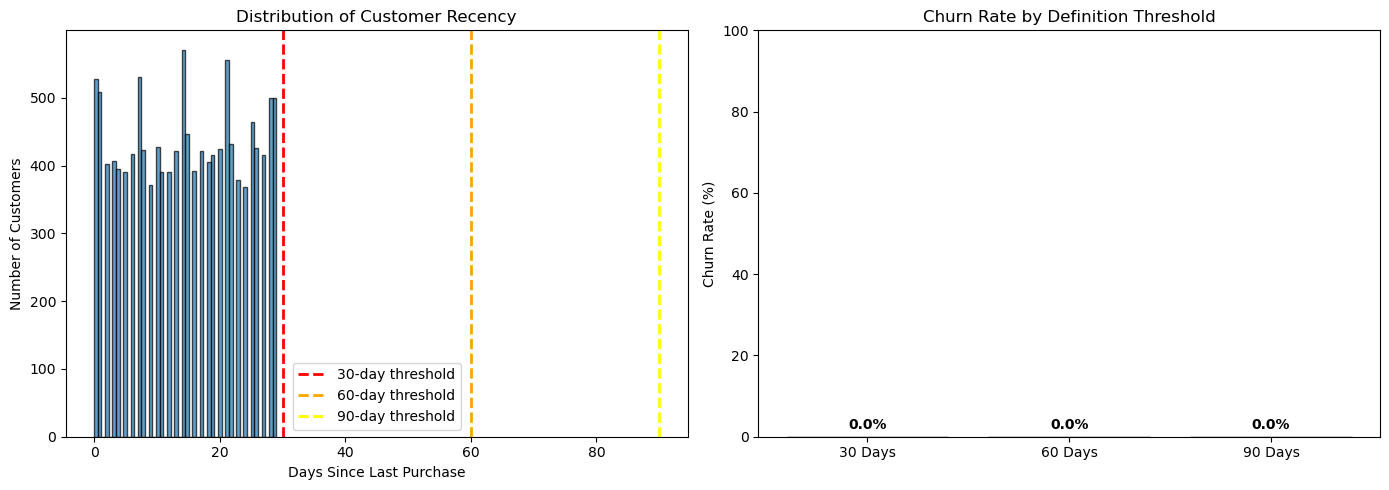

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Days since last purchase distribution
axes[0].hist(customer_agg['days_since_last_purchase'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(30, color='red', linestyle='--', linewidth=2, label='30-day threshold')
axes[0].axvline(60, color='orange', linestyle='--', linewidth=2, label='60-day threshold')
axes[0].axvline(90, color='yellow', linestyle='--', linewidth=2, label='90-day threshold')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Distribution of Customer Recency')
axes[0].legend()

# Churn rate comparison
churn_rates = [
    customer_agg['churned_30d'].mean() * 100,
    customer_agg['churned_60d'].mean() * 100,
    customer_agg['churned_90d'].mean() * 100
]
thresholds = ['30 Days', '60 Days', '90 Days']
axes[1].bar(thresholds, churn_rates, color=['#ff6b6b', '#f9ca24', '#6c5ce7'], edgecolor='black')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Definition Threshold')
axes[1].set_ylim(0, 100)

for i, v in enumerate(churn_rates):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 9.3 RFM Analysis (Recency, Frequency, Monetary)
RFM is critical for customer segmentation and churn prediction

In [19]:
# Calculate RFM Scores (1-5 scale, 5 is best)
customer_agg['R_score'] = pd.qcut(customer_agg['days_since_last_purchase'], q=5, labels=[5,4,3,2,1], duplicates='drop')
customer_agg['F_score'] = pd.qcut(customer_agg['total_orders'].rank(method='first'), q=5, labels=[1,2,3,4,5], duplicates='drop')
customer_agg['M_score'] = pd.qcut(customer_agg['total_sales'].rank(method='first'), q=5, labels=[1,2,3,4,5], duplicates='drop')

# Convert to numeric
customer_agg['R_score'] = customer_agg['R_score'].astype(int)
customer_agg['F_score'] = customer_agg['F_score'].astype(int)
customer_agg['M_score'] = customer_agg['M_score'].astype(int)

# Create RFM Segment
customer_agg['RFM_Score'] = customer_agg['R_score'].astype(str) + customer_agg['F_score'].astype(str) + customer_agg['M_score'].astype(str)
customer_agg['RFM_Total'] = customer_agg['R_score'] + customer_agg['F_score'] + customer_agg['M_score']

# Create customer segments
def segment_customers(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'New Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Lost'
    else:
        return 'Others'

customer_agg['Customer_Segment'] = customer_agg.apply(segment_customers, axis=1)

print("="*60)
print("RFM SEGMENTATION RESULTS")
print("="*60)
print(customer_agg['Customer_Segment'].value_counts())
print("\nSegment Churn Rates (30-day):")
print(customer_agg.groupby('Customer_Segment')['churned_30d'].mean().sort_values(ascending=False) * 100)

customer_agg[['member_id', 'R_score', 'F_score', 'M_score', 'Customer_Segment', 'churned_30d']].head(10)

RFM SEGMENTATION RESULTS
Customer_Segment
At Risk            2917
Loyal Customers    2689
Champions          2266
New Customers      2225
Lost               1963
Others             1060
Name: count, dtype: int64

Segment Churn Rates (30-day):
Customer_Segment
At Risk           0.00
Champions         0.00
Lost              0.00
Loyal Customers   0.00
New Customers     0.00
Others            0.00
Name: churned_30d, dtype: float64


,member_id,R_score,F_score,M_score,Customer_Segment,churned_30d
0,180,3,1,4,Others,0
1,5782,2,1,5,Lost,0
2,6192,5,1,2,New Customers,0
3,12043,5,1,3,New Customers,0
4,21280,3,1,2,Others,0
5,32033,5,1,5,New Customers,0
6,40562,1,1,4,Lost,0
7,45947,3,1,2,Others,0
8,51483,5,1,4,New Customers,0
9,54745,2,1,4,Lost,0


/var/folders/49/z1sxnpr17_l4gjm8n2vplh_40000gn/T/ipykernel_22312/1945101266.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


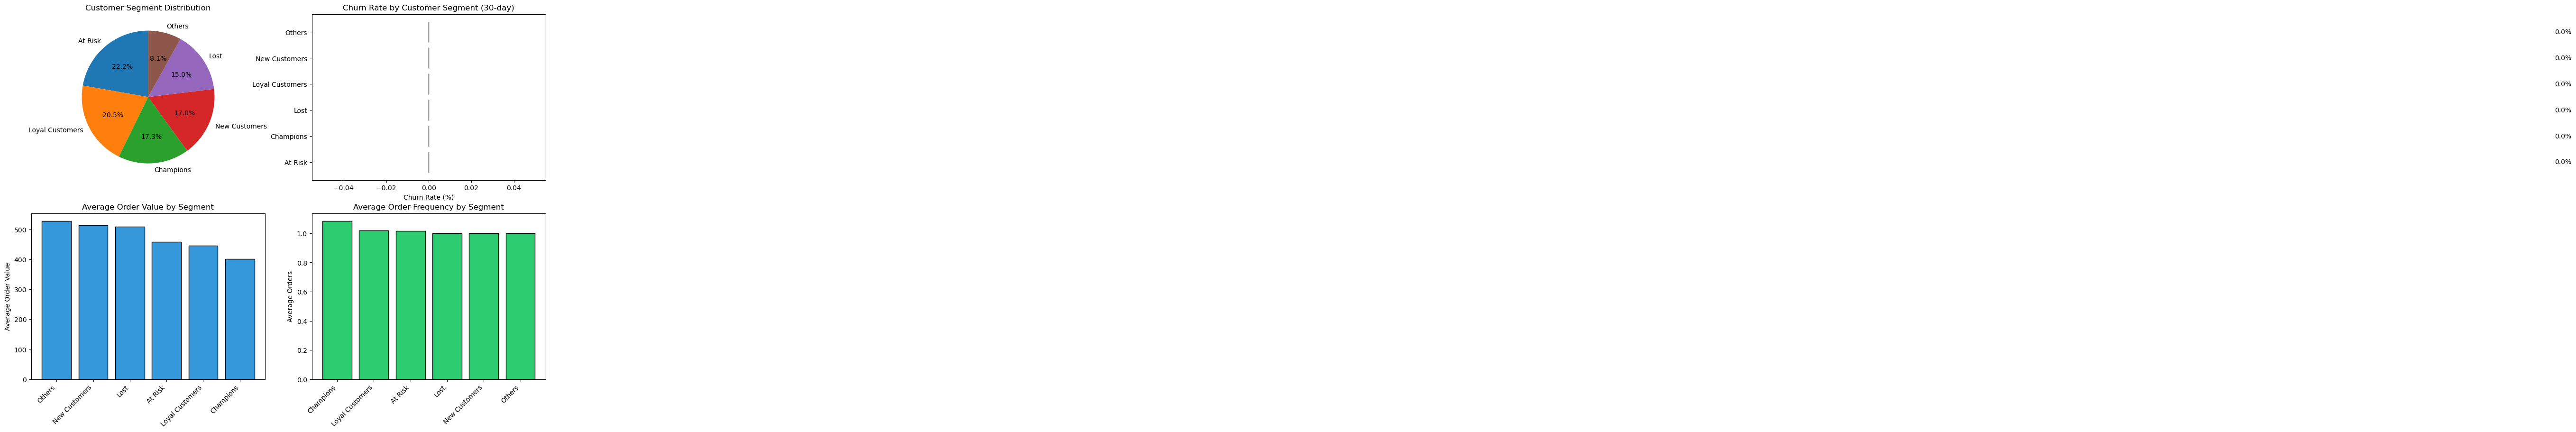

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Segment distribution
segment_counts = customer_agg['Customer_Segment'].value_counts()
axes[0,0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Customer Segment Distribution')

# Churn rate by segment
segment_churn = customer_agg.groupby('Customer_Segment')['churned_30d'].mean().sort_values(ascending=False) * 100
axes[0,1].barh(segment_churn.index, segment_churn.values, color='#e74c3c', edgecolor='black')
axes[0,1].set_xlabel('Churn Rate (%)')
axes[0,1].set_title('Churn Rate by Customer Segment (30-day)')
for i, v in enumerate(segment_churn.values):
    axes[0,1].text(v + 1, i, f'{v:.1f}%', va='center')

# Average order value by segment
segment_aov = customer_agg.groupby('Customer_Segment')['avg_order_value'].mean().sort_values(ascending=False)
axes[1,0].bar(range(len(segment_aov)), segment_aov.values, color='#3498db', edgecolor='black')
axes[1,0].set_xticks(range(len(segment_aov)))
axes[1,0].set_xticklabels(segment_aov.index, rotation=45, ha='right')
axes[1,0].set_ylabel('Average Order Value')
axes[1,0].set_title('Average Order Value by Segment')

# Order frequency by segment
segment_freq = customer_agg.groupby('Customer_Segment')['total_orders'].mean().sort_values(ascending=False)
axes[1,1].bar(range(len(segment_freq)), segment_freq.values, color='#2ecc71', edgecolor='black')
axes[1,1].set_xticks(range(len(segment_freq)))
axes[1,1].set_xticklabels(segment_freq.index, rotation=45, ha='right')
axes[1,1].set_ylabel('Average Orders')
axes[1,1].set_title('Average Order Frequency by Segment')

plt.tight_layout()
plt.show()

## 10. CHURN DRIVERS ANALYSIS

### 10.1 Refunds as Churn Indicator

REFUND IMPACT ON CHURN

Refund Rate: Churned vs Active Customers
            refund_rate             member_id
                   mean median  std     count
churned_30d                                  
0                  0.04   0.00 0.22     13120

T-test Results:
T-statistic: nan
P-value: nan
Significant difference: No


/var/folders/49/z1sxnpr17_l4gjm8n2vplh_40000gn/T/ipykernel_22312/2343571789.py:18: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = stats.ttest_ind(active_refunds, churned_refunds)
/var/folders/49/z1sxnpr17_l4gjm8n2vplh_40000gn/T/ipykernel_22312/2343571789.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  refund_churn = customer_agg.groupby('refund_bucket')['churned_30d'].mean() * 100


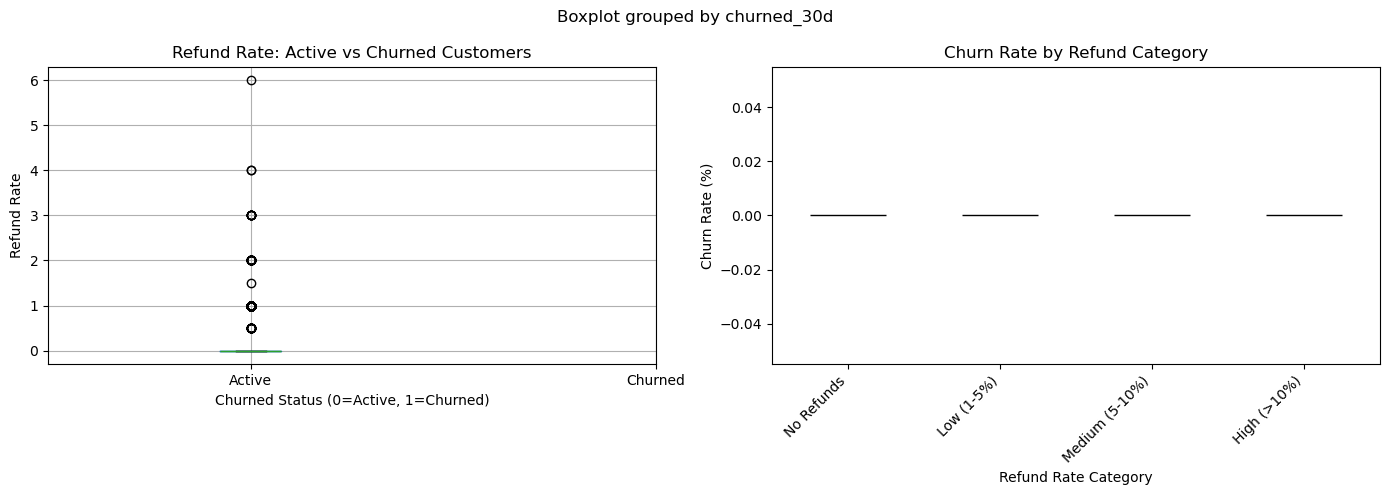

In [21]:
# Analyze relationship between refunds and churn
print("="*60)
print("REFUND IMPACT ON CHURN")
print("="*60)

# Compare refund rates between churned and active customers
refund_comparison = customer_agg.groupby('churned_30d').agg({
    'refund_rate': ['mean', 'median', 'std'],
    'member_id': 'count'
}).round(4)
print("\nRefund Rate: Churned vs Active Customers")
print(refund_comparison)

# Statistical significance
from scipy import stats
active_refunds = customer_agg[customer_agg['churned_30d']==0]['refund_rate']
churned_refunds = customer_agg[customer_agg['churned_30d']==1]['refund_rate']
t_stat, p_value = stats.ttest_ind(active_refunds, churned_refunds)
print(f"\nT-test Results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

customer_agg.boxplot(column='refund_rate', by='churned_30d', ax=axes[0])
axes[0].set_xlabel('Churned Status (0=Active, 1=Churned)')
axes[0].set_ylabel('Refund Rate')
axes[0].set_title('Refund Rate: Active vs Churned Customers')
plt.sca(axes[0])
plt.xticks([1, 2], ['Active', 'Churned'])

# Create refund buckets and churn rate
customer_agg['refund_bucket'] = pd.cut(customer_agg['refund_rate'], 
                                        bins=[0, 0.01, 0.05, 0.1, 1.0], 
                                        labels=['No Refunds', 'Low (1-5%)', 'Medium (5-10%)', 'High (>10%)'])
refund_churn = customer_agg.groupby('refund_bucket')['churned_30d'].mean() * 100
refund_churn.plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_xlabel('Refund Rate Category')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Refund Category')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 10.2 Promotional/Voucher Dependency Analysis

/var/folders/49/z1sxnpr17_l4gjm8n2vplh_40000gn/T/ipykernel_22312/2688010429.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  voucher_churn = customer_agg.groupby('voucher_dependency')['churned_30d'].mean() * 100


VOUCHER USAGE & CHURN RELATIONSHIP

Voucher Dependency Distribution:
voucher_dependency
Very High (>75%)    13120
Low (<25%)              0
Medium (25-50%)         0
High (50-75%)           0
Name: count, dtype: int64

Churn Rate by Voucher Dependency:
voucher_dependency
Low (<25%)          NaN
Medium (25-50%)     NaN
High (50-75%)       NaN
Very High (>75%)   0.00
Name: churned_30d, dtype: float64


/var/folders/49/z1sxnpr17_l4gjm8n2vplh_40000gn/T/ipykernel_22312/2688010429.py:46: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


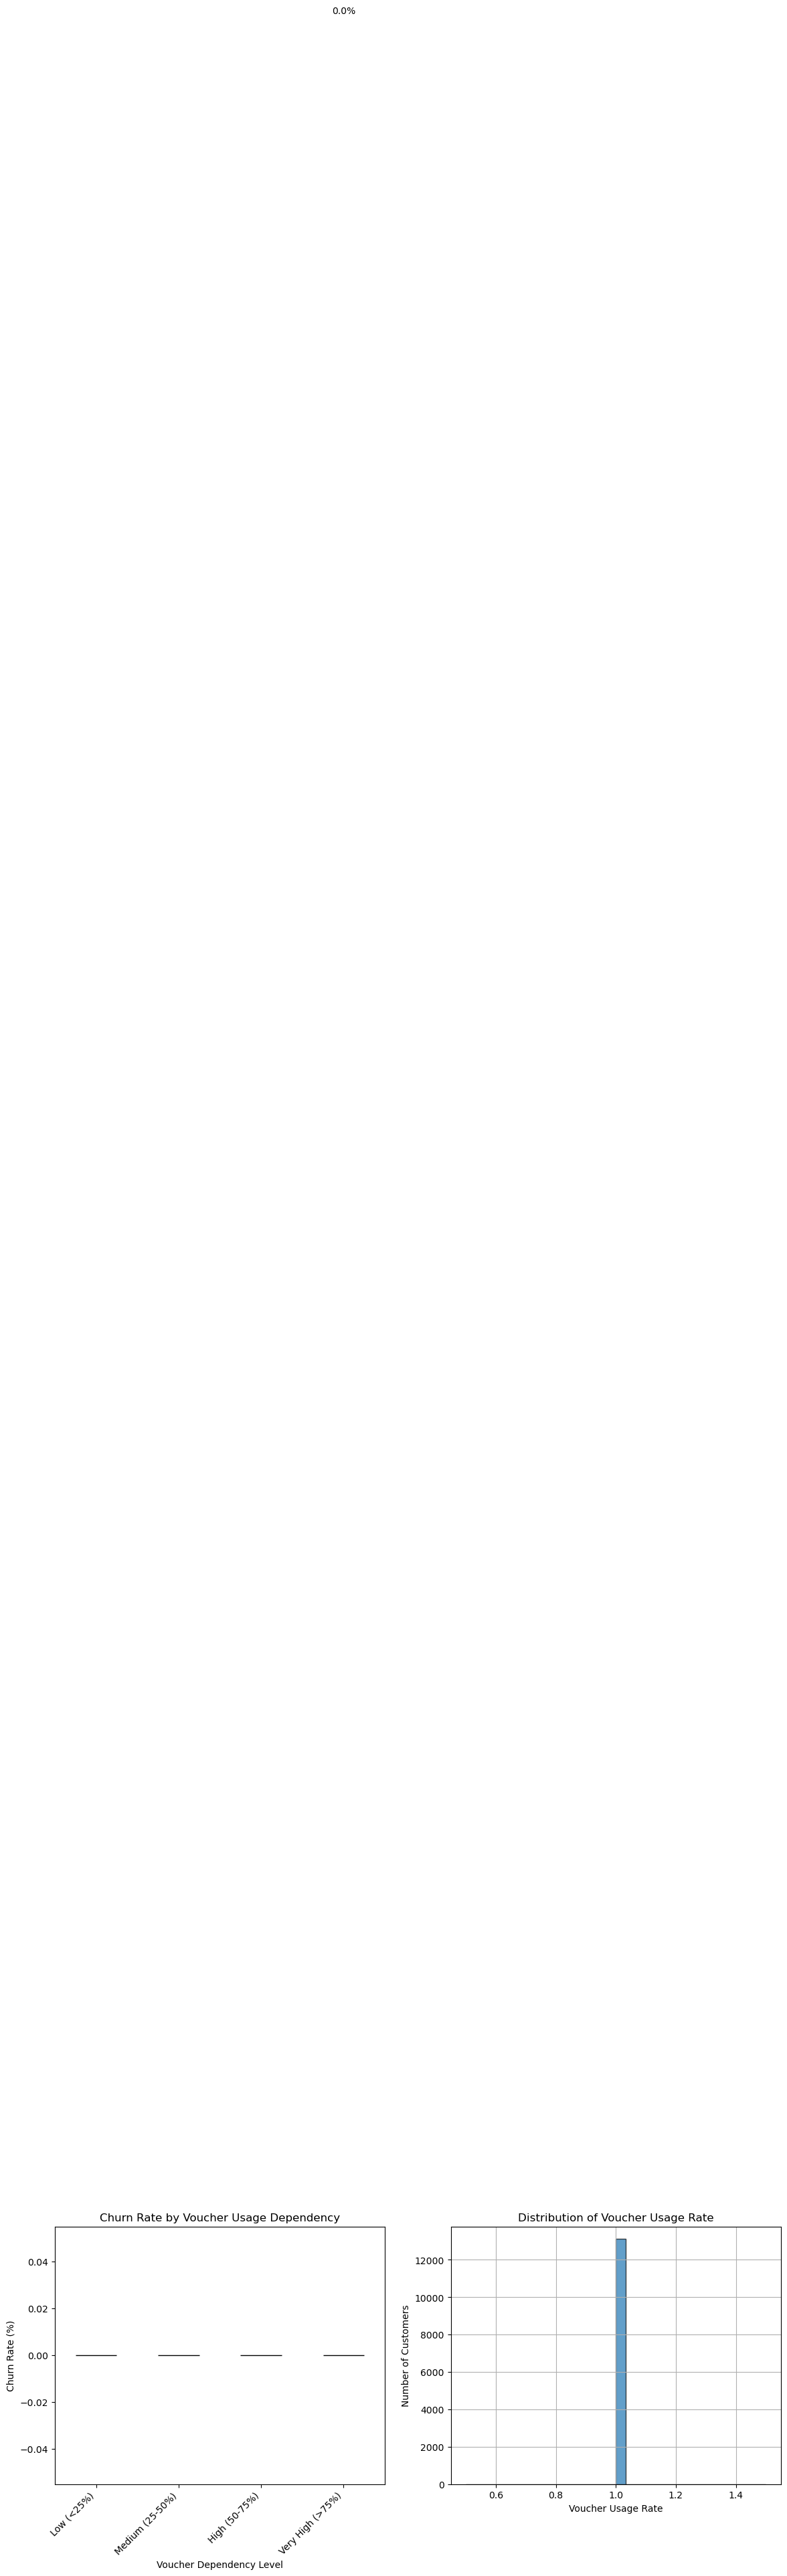

In [22]:
# Analyze voucher usage patterns
df['used_voucher'] = df['evoucher_code'].notna().astype(int)

# Aggregate voucher usage per customer
voucher_agg = df.groupby('member_id').agg({
    'used_voucher': ['sum', 'mean'],
    'source_order_header_id': 'count'
}).reset_index()
voucher_agg.columns = ['member_id', 'total_voucher_orders', 'voucher_usage_rate', 'total_orders']

# Merge with customer data
customer_agg = customer_agg.merge(voucher_agg, on='member_id', how='left')

# Create voucher dependency segments
customer_agg['voucher_dependency'] = pd.cut(customer_agg['voucher_usage_rate'], 
                                             bins=[0, 0.25, 0.5, 0.75, 1.0],
                                             labels=['Low (<25%)', 'Medium (25-50%)', 'High (50-75%)', 'Very High (>75%)'])

print("="*60)
print("VOUCHER USAGE & CHURN RELATIONSHIP")
print("="*60)
print("\nVoucher Dependency Distribution:")
print(customer_agg['voucher_dependency'].value_counts())

print("\nChurn Rate by Voucher Dependency:")
voucher_churn = customer_agg.groupby('voucher_dependency')['churned_30d'].mean() * 100
print(voucher_churn)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

voucher_churn.plot(kind='bar', ax=axes[0], color='#9b59b6', edgecolor='black')
axes[0].set_xlabel('Voucher Dependency Level')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Voucher Usage Dependency')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(voucher_churn.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center')

# Voucher usage distribution
customer_agg['voucher_usage_rate'].hist(bins=30, ax=axes[1], edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Voucher Usage Rate')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Distribution of Voucher Usage Rate')

plt.tight_layout()
plt.show()

## 11. COHORT ANALYSIS - Retention Patterns Over Time

### 11.1 Customer Cohort by First Purchase Month

COHORT RETENTION MATRIX (%) - Last 10 Cohorts
months_since_first      0
cohort_month             
2025-11            100.00


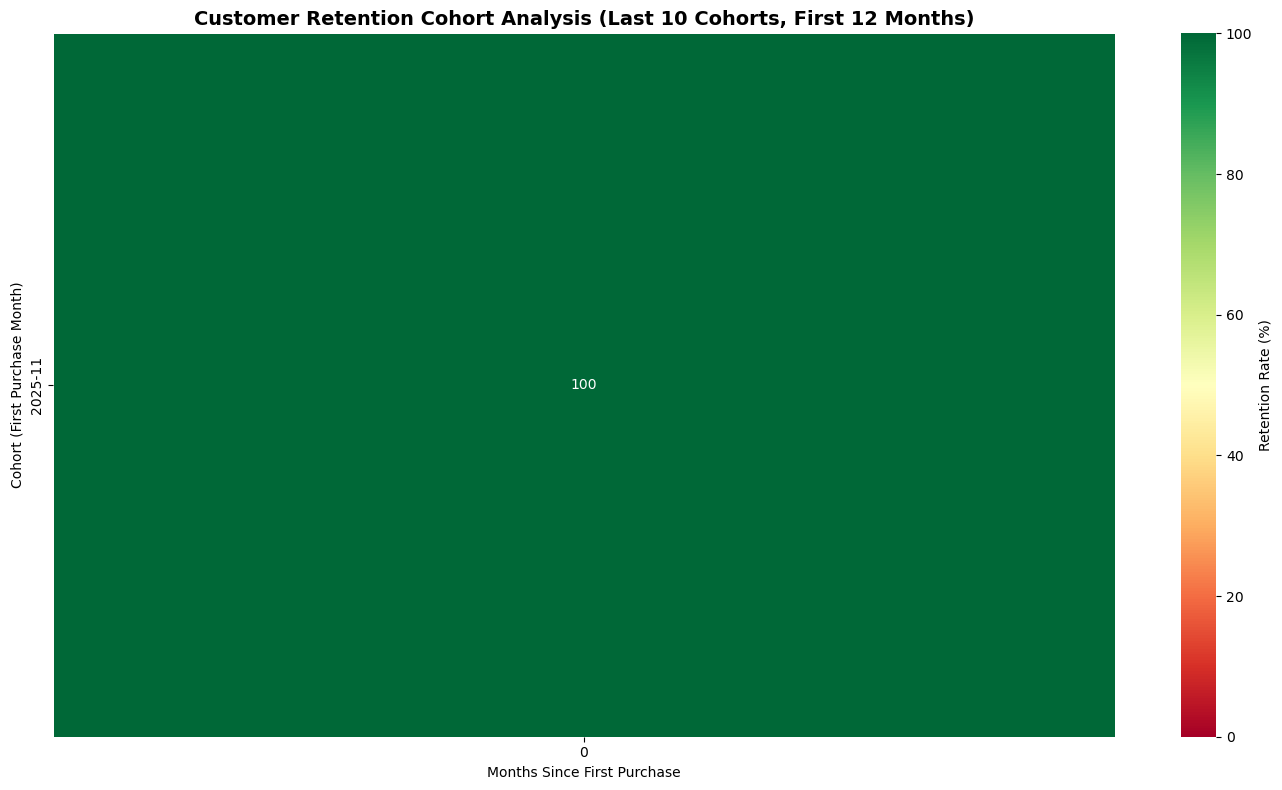


Average Retention Rate by Month:
months_since_first
0   100.00
dtype: float64


In [23]:
# Create cohort based on first purchase
df['order_month'] = df['delivery_date'].dt.to_period('M')
df['cohort_month'] = df.groupby('member_id')['delivery_date'].transform('min').dt.to_period('M')

# Calculate months since first purchase
df['months_since_first'] = (df['order_month'] - df['cohort_month']).apply(lambda x: x.n)

# Create cohort table
cohort_data = df.groupby(['cohort_month', 'months_since_first'])['member_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='months_since_first', values='member_id')

# Calculate retention rate
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

# Display retention matrix (first 12 months and last 10 cohorts)
print("="*60)
print("COHORT RETENTION MATRIX (%) - Last 10 Cohorts")
print("="*60)
print(retention_matrix.iloc[-10:, :12].round(1))

# Visualize cohort heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix.iloc[-10:, :12], 
            annot=True, 
            fmt='.0f', 
            cmap='RdYlGn', 
            vmin=0, 
            vmax=100,
            cbar_kws={'label': 'Retention Rate (%)'},
            linewidths=0.5)
plt.title('Customer Retention Cohort Analysis (Last 10 Cohorts, First 12 Months)', fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.show()

# Calculate average retention by month
avg_retention = retention_matrix.mean(axis=0)[:12]
print("\nAverage Retention Rate by Month:")
print(avg_retention.round(2))

## 12. FEATURE IMPORTANCE FOR CHURN PREDICTION

### 12.1 Correlation Analysis with Churn

FEATURE CORRELATION WITH CHURN (30-DAY)
days_since_last_purchase   NaN
total_orders_y             NaN
avg_order_value            NaN
avg_basket_size            NaN
refund_rate                NaN
customer_lifetime_days     NaN
voucher_usage_rate         NaN
R_score                    NaN
F_score                    NaN
M_score                    NaN
churned_30d                NaN
Name: churned_30d, dtype: float64


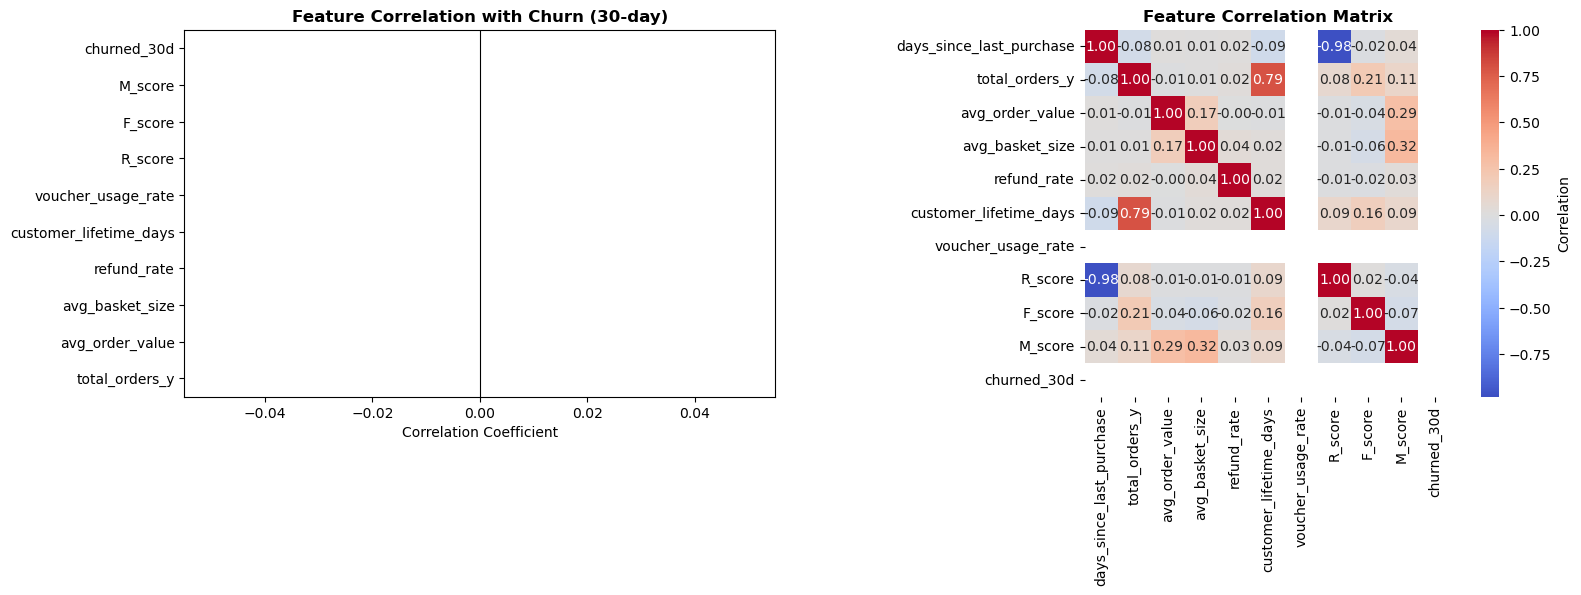

In [26]:
# Select numerical features for correlation analysis
features_for_modeling = [
    'days_since_last_purchase', 'total_orders_y', 'avg_order_value', 
    'avg_basket_size', 'refund_rate', 'customer_lifetime_days',
    'voucher_usage_rate', 'R_score', 'F_score', 'M_score', 'churned_30d'
]

# Calculate correlation with churn
correlation_data = customer_agg[features_for_modeling].corr()['churned_30d'].sort_values(ascending=False)
print("="*60)
print("FEATURE CORRELATION WITH CHURN (30-DAY)")
print("="*60)
print(correlation_data)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation bar plot
correlation_data[1:].plot(kind='barh', ax=axes[0], color=['red' if x > 0 else 'green' for x in correlation_data[1:]])
axes[0].set_xlabel('Correlation Coefficient')
axes[0].set_title('Feature Correlation with Churn (30-day)', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)

# Correlation heatmap
sns.heatmap(customer_agg[features_for_modeling].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            ax=axes[1],
            cbar_kws={'label': 'Correlation'})
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()


## 13. KEY INSIGHTS & BUSINESS RECOMMENDATIONS

### 13.1 Summary of Key Findings

In [27]:
# Generate automated insights
print("="*80)
print("EXECUTIVE SUMMARY - KEY FINDINGS FOR RETENTION STRATEGY")
print("="*80)

# 1. Overall churn metrics
total_customers = len(customer_agg)
churned_30d = customer_agg['churned_30d'].sum()
churn_rate_30d = customer_agg['churned_30d'].mean() * 100

print(f"\n1. CURRENT SITUATION")
print(f"   • Total Customers: {total_customers:,}")
print(f"   • 30-Day Churn Rate: {churn_rate_30d:.2f}%")
print(f"   • Churned Customers: {churned_30d:,}")
print(f"   • Target: Reduce churn by 3% → Target Rate: {churn_rate_30d - 3:.2f}%")

# 2. High-risk segments
print(f"\n2. HIGH-RISK CUSTOMER SEGMENTS")
segment_risk = customer_agg.groupby('Customer_Segment')['churned_30d'].agg(['mean', 'count'])
segment_risk['total_churned'] = (segment_risk['mean'] * segment_risk['count']).astype(int)
segment_risk = segment_risk.sort_values('mean', ascending=False)
for idx, row in segment_risk.head(3).iterrows():
    print(f"   • {idx}: {row['mean']*100:.1f}% churn rate ({row['total_churned']:,} customers)")

# 3. Key churn drivers
print(f"\n3. TOP CHURN DRIVERS (Correlation with Churn)")
top_drivers = correlation_data[1:6].abs().sort_values(ascending=False)
for feature, corr in top_drivers.items():
    print(f"   • {feature}: {corr:.3f}")

# 4. Refund impact
avg_refund_churned = customer_agg[customer_agg['churned_30d']==1]['refund_rate'].mean()
avg_refund_active = customer_agg[customer_agg['churned_30d']==0]['refund_rate'].mean()
print(f"\n4. SERVICE QUALITY IMPACT")
print(f"   • Refund Rate (Churned): {avg_refund_churned*100:.2f}%")
print(f"   • Refund Rate (Active): {avg_refund_active*100:.2f}%")
print(f"   • Difference: {(avg_refund_churned - avg_refund_active)*100:.2f}pp")

# 5. Voucher dependency
high_voucher_churn = customer_agg[customer_agg['voucher_usage_rate'] > 0.5]['churned_30d'].mean() * 100
low_voucher_churn = customer_agg[customer_agg['voucher_usage_rate'] <= 0.25]['churned_30d'].mean() * 100
print(f"\n5. PROMOTIONAL DEPENDENCY")
print(f"   • Churn Rate (High Voucher Users >50%): {high_voucher_churn:.1f}%")
print(f"   • Churn Rate (Low Voucher Users <25%): {low_voucher_churn:.1f}%")

# 6. Recommended actions
print(f"\n6. STRATEGIC RECOMMENDATIONS TO ACHIEVE 3% REDUCTION")
print(f"   ✓ Target 'At Risk' segment with re-engagement campaigns")
print(f"   ✓ Implement proactive service recovery for customers with refunds")
print(f"   ✓ Reduce voucher dependency through value-based marketing")
print(f"   ✓ Deploy predictive churn model to identify customers 15-20 days before churn")
print(f"   ✓ Personalize retention offers based on RFM segments")
print(f"   ✓ Focus on 'New Customers' with onboarding programs to improve early retention")

print("\n" + "="*80)

EXECUTIVE SUMMARY - KEY FINDINGS FOR RETENTION STRATEGY

1. CURRENT SITUATION
   • Total Customers: 13,120
   • 30-Day Churn Rate: 0.00%
   • Churned Customers: 0
   • Target: Reduce churn by 3% → Target Rate: -3.00%

2. HIGH-RISK CUSTOMER SEGMENTS
   • At Risk: 0.0% churn rate (0.0 customers)
   • Champions: 0.0% churn rate (0.0 customers)
   • Lost: 0.0% churn rate (0.0 customers)

3. TOP CHURN DRIVERS (Correlation with Churn)
   • total_orders_y: nan
   • avg_order_value: nan
   • avg_basket_size: nan
   • refund_rate: nan
   • customer_lifetime_days: nan

4. SERVICE QUALITY IMPACT
   • Refund Rate (Churned): nan%
   • Refund Rate (Active): 3.60%
   • Difference: nanpp

5. PROMOTIONAL DEPENDENCY
   • Churn Rate (High Voucher Users >50%): 0.0%
   • Churn Rate (Low Voucher Users <25%): nan%

6. STRATEGIC RECOMMENDATIONS TO ACHIEVE 3% REDUCTION
   ✓ Target 'At Risk' segment with re-engagement campaigns
   ✓ Implement proactive service recovery for customers with refunds
   ✓ Reduce vou